## Video Inference

Given entire pipeline, we now want to expand our model deployment to also support video. This looks like:

- Input: Video file (.mp4)
- Output: Video file overlayed with bounding box and keypoints for each individual frame. Prediction of each frame's current pose under bounding box. Exported as (.mp4) file

## Implementation

### 1) Setup

In [9]:
from pathlib import Path
import sys
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision import transforms

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "inference":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.bbox_detection import BBoxDetectionModel
from models.keypoint_detection import KeypointDetectionModel
from models.keypoint_attention_detection import KeypointAttentionDetectionModel
from models.pose_classification import PoseClassificationModel
from preprocessing.pil_preprocessing import crop_pil, letterbox_resize, norm_bbox_to_xyxy_pixels
from preprocessing.tensor_preprocessing import heatmaps_to_keypoints, normalize_keypoints_xy



DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Repo root:", PROJECT_ROOT)
print("Device:", DEVICE)

Repo root: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection
Device: cpu


In [10]:
default_input = PROJECT_ROOT / "datasets" / "davis" / "lucas.mp4"
if default_input.exists():
    INPUT_VIDEO_PATH = default_input
else:
    candidates = sorted((PROJECT_ROOT / "datasets").rglob("*.mp4"))
    if not candidates:
        raise FileNotFoundError("No input mp4 found under datasets/. Set INPUT_VIDEO_PATH manually.")
    INPUT_VIDEO_PATH = candidates[0]

OUTPUT_VIDEO_PATH = PROJECT_ROOT / "outputs" / f"{INPUT_VIDEO_PATH.stem}_predictions.mp4"

# Prefer e2e bundle for all three stages
E2E_CKPT_PATH = PROJECT_ROOT / "exports" / "colab_e2e_best_2.pt"
BBOX_CKPT_PATH = PROJECT_ROOT / "exports" / "bbox_best.pt"
KEYPOINT_CKPT_PATH = PROJECT_ROOT / "exports" / "keypoint_best_state_dict.pt"
POSE_CKPT_PATH = E2E_CKPT_PATH

BBOX_IMAGE_SIZE = (256, 256)
KEYPOINT_IMAGE_SIZE = (128, 128)

bbox_transform = transforms.Compose([
    transforms.Resize(BBOX_IMAGE_SIZE),
    transforms.ToTensor(),
])

OUTPUT_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)
print("Input:", INPUT_VIDEO_PATH)
print("Output:", OUTPUT_VIDEO_PATH)
print("BBox model input size (H, W):", BBOX_IMAGE_SIZE)
print("E2E checkpoint:", E2E_CKPT_PATH)

Input: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/datasets/davis/lucas.mp4
Output: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/outputs/lucas_predictions.mp4
BBox model input size (H, W): (256, 256)
E2E checkpoint: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/exports/colab_e2e_best_2.pt


### 2) Load Models

In [12]:
pose_payload = torch.load(POSE_CKPT_PATH, map_location=DEVICE)
is_e2e_bundle = (
    isinstance(pose_payload, dict)
    and "bbox_model_state" in pose_payload
    and "keypoint_model_state" in pose_payload
    and "pose_model_state" in pose_payload
)

if is_e2e_bundle:
    # Stage 1 from e2e
    bbox_model = BBoxDetectionModel().to(DEVICE)
    bbox_model.load_state_dict(pose_payload["bbox_model_state"])
    bbox_model.eval()

    # Stage 2 from e2e (infer architecture by state keys)
    keypoint_state = pose_payload["keypoint_model_state"]
    keypoint_num_keypoints = 18
    kp_h = int(pose_payload.get("keypoint_image_height", 128))
    kp_w = int(pose_payload.get("keypoint_image_width", 128))
    KEYPOINT_IMAGE_SIZE = (kp_h, kp_w)

    has_attention_keys = any(k.startswith("encoder.stem.") for k in keypoint_state.keys())
    if has_attention_keys:
        keypoint_model = KeypointAttentionDetectionModel(num_keypoints=keypoint_num_keypoints).to(DEVICE)
    else:
        keypoint_model = KeypointDetectionModel(num_keypoints=keypoint_num_keypoints).to(DEVICE)
    keypoint_model.load_state_dict(keypoint_state)
    keypoint_model.eval()

    # Stage 3 from e2e
    pose_label_names = pose_payload.get("label_names", ["backhand", "forehand", "ready_position", "serve"])
    pose_args = pose_payload.get("args", {}) if isinstance(pose_payload.get("args", {}), dict) else {}
    pose_model = PoseClassificationModel(
        num_keypoints=keypoint_num_keypoints,
        num_classes=len(pose_label_names),
        hidden_dim=int(pose_args.get("hidden_dim", 384)),
        dropout=float(pose_args.get("dropout", 0.4)),
        visibility_threshold=float(pose_args.get("visibility_threshold", 0.0)),
    ).to(DEVICE)
    pose_model.load_state_dict(pose_payload["pose_model_state"])
    pose_model.eval()

else:
    # Fallback: legacy stage-specific checkpoints
    bbox_model = BBoxDetectionModel().to(DEVICE)
    bbox_state = torch.load(BBOX_CKPT_PATH, map_location=DEVICE)
    if isinstance(bbox_state, dict) and "model_state" in bbox_state:
        bbox_model.load_state_dict(bbox_state["model_state"])
    else:
        bbox_model.load_state_dict(bbox_state)
    bbox_model.eval()

    keypoint_payload = torch.load(KEYPOINT_CKPT_PATH, map_location=DEVICE)
    keypoint_num_keypoints = int(keypoint_payload["num_keypoints"])
    kp_h = int(keypoint_payload.get("image_height", 128))
    kp_w = int(keypoint_payload.get("image_width", 128))
    KEYPOINT_IMAGE_SIZE = (kp_h, kp_w)
    keypoint_model = KeypointDetectionModel(num_keypoints=keypoint_num_keypoints).to(DEVICE)
    keypoint_model.load_state_dict(keypoint_payload["model_state"])
    keypoint_model.eval()

    pose_label_names = pose_payload.get("label_names", ["backhand", "forehand", "ready_position", "serve"])
    pose_model = PoseClassificationModel(num_keypoints=keypoint_num_keypoints, num_classes=len(pose_label_names)).to(DEVICE)
    if isinstance(pose_payload, dict) and "model_state" in pose_payload:
        pose_model.load_state_dict(pose_payload["model_state"])
    else:
        pose_model.load_state_dict(pose_payload)
    pose_model.eval()

print("Loaded bbox, keypoint, and pose models.")
print("Using e2e bundle:", is_e2e_bundle)
print("Keypoint model:", keypoint_model.__class__.__name__)
print("Keypoint image size:", KEYPOINT_IMAGE_SIZE)
print("Pose labels:", pose_label_names)

Loaded bbox, keypoint, and pose models.
Using e2e bundle: True
Keypoint model: KeypointDetectionModel
Keypoint image size: (128, 128)
Pose labels: ['Backhand', 'Forehand', 'Ready_Position', 'Serve']


### 3) Geometry + Frame Inference Helpers

In [4]:
def letterbox_params(orig_w: int, orig_h: int, target_h: int, target_w: int):
    scale = min(target_w / float(orig_w), target_h / float(orig_h))
    new_w = max(1, int(round(orig_w * scale)))
    new_h = max(1, int(round(orig_h * scale)))
    pad_x = (target_w - new_w) / 2.0
    pad_y = (target_h - new_h) / 2.0
    return scale, pad_x, pad_y


def to_pil_rgb(frame_bgr: np.ndarray) -> Image.Image:
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(frame_rgb)


def to_xyxy_pixels(bbox_pred: torch.Tensor, image_width: int, image_height: int):
    bbox = bbox_pred.detach().cpu().view(-1)
    if bbox.numel() != 4:
        raise ValueError(f"Expected bbox prediction with 4 values, got shape {tuple(bbox_pred.shape)}")

    x, y, w, h = bbox.tolist()

    likely_normalized = max(abs(x), abs(y), abs(w), abs(h)) <= 1.5
    if likely_normalized:
        x = x * image_width
        y = y * image_height
        w = w * image_width
        h = h * image_height

    x1 = int(round(x))
    y1 = int(round(y))
    x2 = int(round(x + w))
    y2 = int(round(y + h))

    x1 = max(0, min(x1, image_width - 1))
    y1 = max(0, min(y1, image_height - 1))
    x2 = max(x1 + 1, min(x2, image_width))
    y2 = max(y1 + 1, min(y2, image_height))

    return x1, y1, x2, y2


def infer_single_frame(frame_bgr: np.ndarray):
    frame_h, frame_w = frame_bgr.shape[:2]
    pil_frame = to_pil_rgb(frame_bgr)

    bbox_input_tensor = bbox_transform(pil_frame).to(DEVICE)
    with torch.no_grad():
        bbox_pred = bbox_model(bbox_input_tensor.unsqueeze(0)).squeeze(0)

    x1, y1, x2, y2 = to_xyxy_pixels(bbox_pred, frame_w, frame_h)

    crop_w = max(1, x2 - x1)
    crop_h = max(1, y2 - y1)
    crop = crop_pil(pil_frame, (x1, y1, x2, y2))
    kp_in = letterbox_resize(crop, KEYPOINT_IMAGE_SIZE)
    kp_tensor = torch.from_numpy(np.array(kp_in).transpose(2, 0, 1)).float().div(255.0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        heatmaps = keypoint_model(kp_tensor)

    kp_xyc = heatmaps_to_keypoints(heatmaps)[0].detach().cpu().numpy()

    kp_h, kp_w = KEYPOINT_IMAGE_SIZE
    pose_features = normalize_keypoints_xy(torch.from_numpy(kp_xyc).unsqueeze(0), kp_h, kp_w)[0].numpy()
    pose_tensor = torch.from_numpy(pose_features).float().unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pose_logits = pose_model(pose_tensor)
        pose_probs = torch.softmax(pose_logits, dim=-1)[0].detach().cpu().numpy()

    pose_idx = int(np.argmax(pose_probs))
    pose_label = pose_label_names[pose_idx]
    pose_conf = float(pose_probs[pose_idx])

    scale, pad_x, pad_y = letterbox_params(crop_w, crop_h, kp_h, kp_w)

    keypoints_frame = []
    for x_kp, y_kp, c_kp in kp_xyc:
        x_crop = (float(x_kp) - pad_x) / scale
        y_crop = (float(y_kp) - pad_y) / scale
        x_frame = np.clip(x1 + x_crop, 0, frame_w - 1)
        y_frame = np.clip(y1 + y_crop, 0, frame_h - 1)
        keypoints_frame.append((float(x_frame), float(y_frame), float(c_kp)))

    return {
        "bbox": (x1, y1, x2, y2),
        "keypoints": keypoints_frame,
        "pose_label": pose_label,
        "pose_conf": pose_conf,
    }


def draw_prediction(frame_bgr: np.ndarray, pred: dict, kp_conf_threshold: float = 0.1) -> np.ndarray:
    annotated = frame_bgr.copy()
    x1, y1, x2, y2 = pred["bbox"]

    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

    text = f"{pred['pose_label']} ({pred['pose_conf']:.2f})"
    text_y = y2 + 22
    if text_y >= annotated.shape[0]:
        text_y = max(18, y1 - 8)
    cv2.putText(annotated, text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2, cv2.LINE_AA)

    for x_kp, y_kp, c_kp in pred["keypoints"]:
        if c_kp >= kp_conf_threshold:
            cv2.circle(annotated, (int(round(x_kp)), int(round(y_kp))), 3, (0, 0, 255), -1)

    return annotated

### 4) Run Video Inference + Export

In [5]:
if not INPUT_VIDEO_PATH.exists():
    raise FileNotFoundError(f"Input video not found: {INPUT_VIDEO_PATH}")

cap = cv2.VideoCapture(str(INPUT_VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Could not open input video: {INPUT_VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
if not fps or fps <= 0:
    fps = 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
if not writer.isOpened():
    cap.release()
    raise RuntimeError(f"Could not open output writer: {OUTPUT_VIDEO_PATH}")

processed = 0
start_time = time.time()

while True:
    ok, frame = cap.read()
    if not ok:
        break

    pred = infer_single_frame(frame)
    annotated = draw_prediction(frame, pred)
    writer.write(annotated)
    processed += 1

cap.release()
writer.release()

elapsed = max(1e-6, time.time() - start_time)
print(f"Processed frames: {processed}/{frame_count}")
print(f"Elapsed: {elapsed:.2f}s | Throughput: {processed / elapsed:.2f} fps")
print(f"Saved: {OUTPUT_VIDEO_PATH}")

Processed frames: 3492/3492
Elapsed: 155.78s | Throughput: 22.42 fps
Saved: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection/outputs/lucas_predictions.mp4


### 5) Validate Output

Video notebook bbox: (1107, 482, 1426, 1041)
Reference (inference.ipynb) bbox: (1107, 482, 1426, 1041)
Exact match: True
IoU: 1.000000


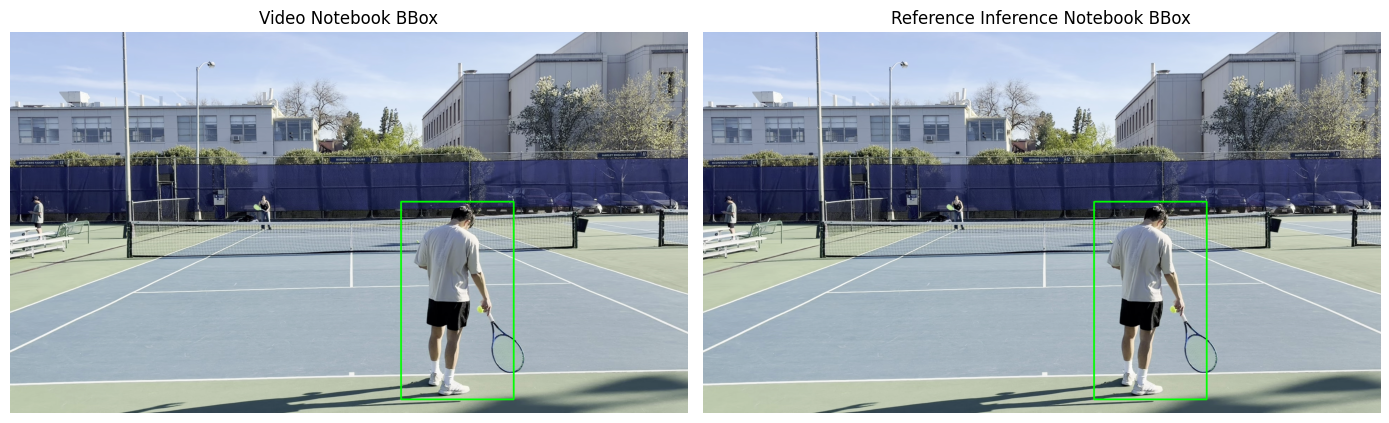

In [6]:
def bbox_iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = max(1, area_a + area_b - inter)

    return inter / union


cap = cv2.VideoCapture(str(INPUT_VIDEO_PATH))
ok, frame = cap.read()
cap.release()
if not ok:
    raise RuntimeError("Could not read first frame for bbox validation.")

pred_video = infer_single_frame(frame)
bbox_video = pred_video["bbox"]

pil_frame = to_pil_rgb(frame)
with torch.no_grad():
    bbox_input_tensor_ref = bbox_transform(pil_frame).to(DEVICE)
    bbox_pred_ref = bbox_model(bbox_input_tensor_ref.unsqueeze(0)).squeeze(0)
bbox_ref = to_xyxy_pixels(bbox_pred_ref, frame.shape[1], frame.shape[0])

iou = bbox_iou(bbox_video, bbox_ref)
print("Video notebook bbox:", bbox_video)
print("Reference (inference.ipynb) bbox:", bbox_ref)
print("Exact match:", bbox_video == bbox_ref)
print(f"IoU: {iou:.6f}")

left = frame.copy()
right = frame.copy()
cv2.rectangle(left, (bbox_video[0], bbox_video[1]), (bbox_video[2], bbox_video[3]), (0, 255, 0), 3)
cv2.rectangle(right, (bbox_ref[0], bbox_ref[1]), (bbox_ref[2], bbox_ref[3]), (0, 255, 0), 3)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(left, cv2.COLOR_BGR2RGB))
plt.title("Video Notebook BBox")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(right, cv2.COLOR_BGR2RGB))
plt.title("Reference Inference Notebook BBox")
plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
in_cap = cv2.VideoCapture(str(INPUT_VIDEO_PATH))
out_cap = cv2.VideoCapture(str(OUTPUT_VIDEO_PATH))

in_meta = {
    "fps": in_cap.get(cv2.CAP_PROP_FPS),
    "width": int(in_cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
    "height": int(in_cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    "frames": int(in_cap.get(cv2.CAP_PROP_FRAME_COUNT)),
}
out_meta = {
    "fps": out_cap.get(cv2.CAP_PROP_FPS),
    "width": int(out_cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
    "height": int(out_cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    "frames": int(out_cap.get(cv2.CAP_PROP_FRAME_COUNT)),
}

in_cap.release()
out_cap.release()

print("Input metadata:", in_meta)
print("Output metadata:", out_meta)

Input metadata: {'fps': 59.97080459112116, 'width': 1920, 'height': 1080, 'frames': 3492}
Output metadata: {'fps': 59.97, 'width': 1920, 'height': 1080, 'frames': 3492}


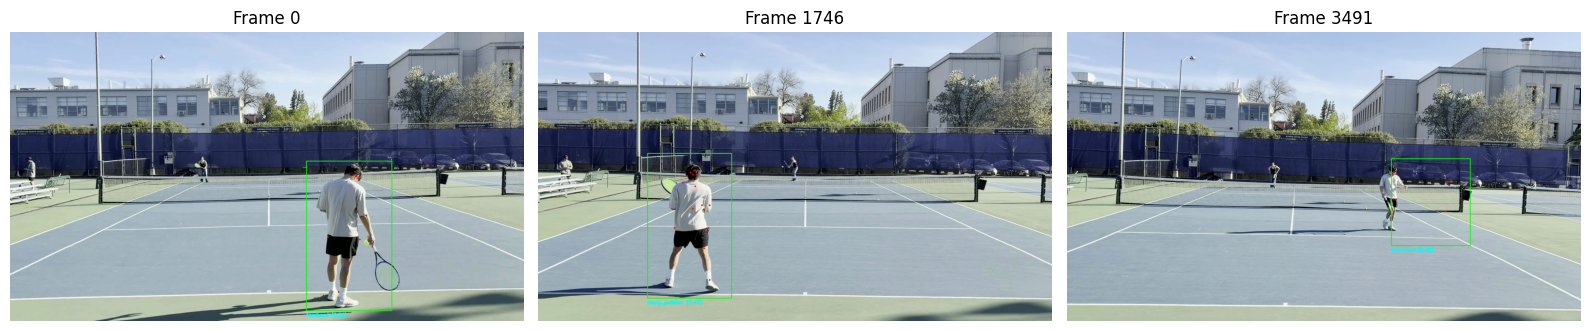

In [8]:
cap = cv2.VideoCapture(str(OUTPUT_VIDEO_PATH))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
indices = sorted(set([0, max(0, total // 2), max(0, total - 1)]))

frames = []
for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    if ok:
        frames.append((idx, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
cap.release()

if frames:
    plt.figure(figsize=(16, 5))
    for i, (idx, frame_rgb) in enumerate(frames, start=1):
        plt.subplot(1, len(frames), i)
        plt.imshow(frame_rgb)
        plt.title(f"Frame {idx}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No frames available for preview.")

### Usage

- Set `INPUT_VIDEO_PATH` and `OUTPUT_VIDEO_PATH` in Setup.
- Run all cells from top to bottom.
- Open the generated output mp4 in `evaluation_outputs/`.